# Unit execution for `bloch_trajectory_plot.py`

This notebook is for checking and tweaking the Bloch-trajectory plotting utilities.

You can directly edit:
- the Bloch vectors,
- the density matrices,
- the view angles,
- whether you compare exact and obtained trajectories.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from plot.bloch_trajectory_plot import (
    BlochTrajectory,
    density_matrix_to_bloch_vector,
    density_matrices_to_bloch_vectors,
    make_bloch_trajectory_from_density_matrices,
    plot_bloch_trajectory_comparison,
)

np.set_printoptions(precision=6, suppress=True)


## 1. Directly tweak Bloch vectors

Edit the parametric curve below to test the trajectory plot.


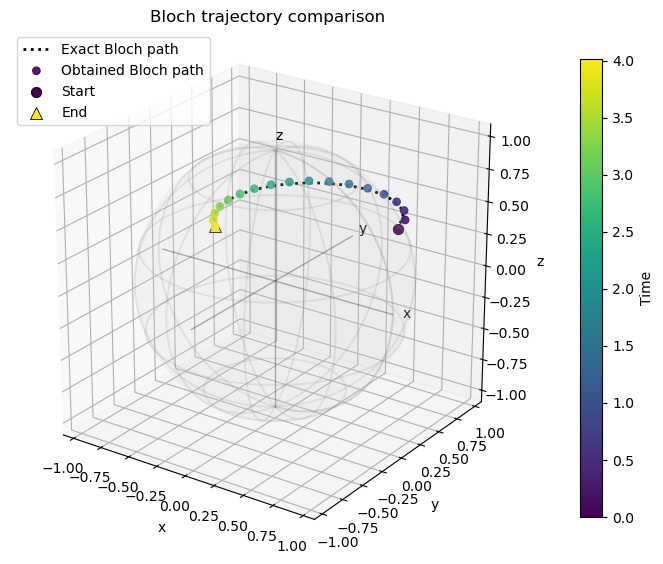

In [2]:
# -------- Tweakable direct Bloch vectors --------
num_points = 90
times = np.linspace(0.0, 4.2, num_points)

# Exact trajectory: edit these formulas freely
r = np.exp(-0.22 * times)
theta = 0.95 * times
z_exact = 0.65 - 0.25 * (1.0 - np.exp(-0.45 * times))
x_exact = r * np.cos(theta)
y_exact = r * np.sin(theta)
vectors_exact = np.column_stack([x_exact, y_exact, z_exact])

# Obtained data: sampled and perturbed
times_obt = times[::5]
x_obt = x_exact[::5] * (1.0 + 0.03 * np.cos(1.4 * times_obt))
y_obt = y_exact[::5] * (1.0 - 0.02 * np.sin(1.2 * times_obt))
z_obt = z_exact[::5] + 0.02 * np.sin(0.9 * times_obt)
vectors_obt = np.column_stack([x_obt, y_obt, z_obt])

traj_exact = BlochTrajectory(times=times, vectors=vectors_exact, label="Bloch path")
traj_obt = BlochTrajectory(times=times_obt, vectors=vectors_obt, label="Bloch path")

fig, ax = plot_bloch_trajectory_comparison(
    traj_exact,
    traj_obt,
    title="Bloch trajectory comparison",
    view_elev=24,
    view_azim=-55,
)
plt.show()


## 2. Build Bloch vectors from density matrices

This is the more natural workflow for your later time-evolution notebooks.


First Bloch vector from rho: [1.   0.   0.75]
Last Bloch vector from rho: [-0.162338 -0.275555  0.297516]


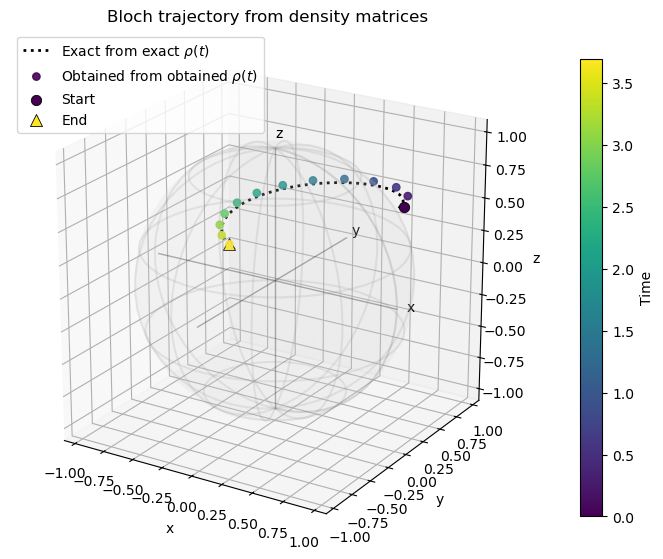

In [3]:
# -------- Tweakable density-matrix trajectory --------
times_rho = np.linspace(0.0, 3.8, 75)

# Define a trajectory through x(t), y(t), z(t), then convert to rho(t)
x_t = np.exp(-0.30 * times_rho) * np.cos(1.1 * times_rho)
y_t = np.exp(-0.30 * times_rho) * np.sin(1.1 * times_rho)
z_t = 0.85 * np.exp(-0.20 * times_rho) - 0.10

rho_list = []
for x, y, z in zip(x_t, y_t, z_t):
    rho = 0.5 * np.array([
        [1 + z, x - 1j * y],
        [x + 1j * y, 1 - z],
    ], dtype=complex)
    rho_list.append(rho)

rho_exact = np.array(rho_list)

# Coarser obtained data
rho_obt = rho_exact[::6].copy()
rho_obt[:, 0, 1] *= (1.0 + 0.04)
rho_obt[:, 1, 0] = np.conj(rho_obt[:, 0, 1])
rho_obt[:, 0, 0] += 0.01
rho_obt[:, 1, 1] -= 0.01

traj_from_rho = make_bloch_trajectory_from_density_matrices(
    times_rho,
    rho_exact,
    label=r"from exact $\rho(t)$",
)
traj_from_rho_obt = make_bloch_trajectory_from_density_matrices(
    times_rho[::6],
    rho_obt,
    label=r"from obtained $\rho(t)$",
)

print("First Bloch vector from rho:", traj_from_rho.vectors[0])
print("Last Bloch vector from rho:", traj_from_rho.vectors[-1])

fig, ax = plot_bloch_trajectory_comparison(
    traj_from_rho,
    traj_from_rho_obt,
    title="Bloch trajectory from density matrices",
)
plt.show()


## 3. Inspect conversion for a single state

This is useful when you want to verify a manual state before using it in a trajectory.


In [4]:
rho_single = np.array([
    [0.70, 0.15 - 0.22j],
    [0.15 + 0.22j, 0.30],
], dtype=complex)

bloch_single = density_matrix_to_bloch_vector(rho_single)
print("rho_single =")
print(rho_single)
print("Bloch vector =", bloch_single)


rho_single =
[[0.7 +0.j   0.15-0.22j]
 [0.15+0.22j 0.3 +0.j  ]]
Bloch vector = [0.3  0.44 0.4 ]


## 4. Blank editable template

Replace the vectors below with your own trajectory.


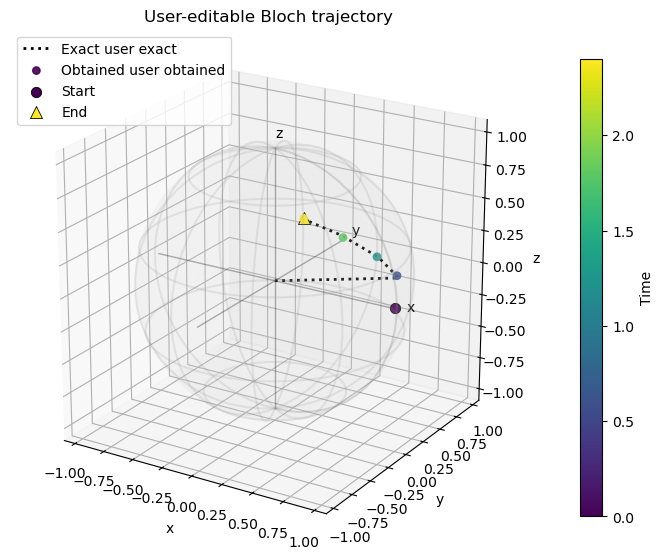

In [5]:
times_user = np.array([0.0, 0.6, 1.2, 1.8, 2.4])
vectors_user_exact = np.array([
    [0.00, 0.00, 0.00],
    [0.82, 0.34, 0.08],
    [0.58, 0.46, 0.15],
    [0.31, 0.40, 0.28],
    [0.10, 0.22, 0.42],
], dtype=float)

vectors_user_obt = np.array([
    [0.98, 0.01, 0.00],
    [0.80, 0.35, 0.09],
    [0.56, 0.48, 0.14],
    [0.33, 0.39, 0.27],
    [0.11, 0.21, 0.43],
], dtype=float)

traj_user_exact = BlochTrajectory(times_user, vectors_user_exact, label="user exact")
traj_user_obt = BlochTrajectory(times_user, vectors_user_obt, label="user obtained")

fig, ax = plot_bloch_trajectory_comparison(
    traj_user_exact,
    traj_user_obt,
    title="User-editable Bloch trajectory",
)
plt.show()
